In [14]:
%load_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt

import sys, os
sys.path.append("../../src/")

from network import FeedForward


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
seed = 1
network = FeedForward(init_steps = 300, seed=seed)

POs = network.get_POs_over_trials(network.w_ef_baseline, network.n_steps, 'baseline')
drift_mag_baseline, drift_rate_baseline, convergence_baseline = network.get_metrics(network.N, network.n_days, network.theta_stim, network.POs)

setting seed: 1


100%|██████████| 840/840 [00:19<00:00, 43.10it/s]


**What happens to the correlation over time as drift occurs?
**

Expectation - it should not change because the drift is not directional, and since we are measuring signal correlation effectively, it should remain static with drift

In [4]:
corrs_initial = network.get_correlations(network.W[:, :, 0])
corrs_final = network.get_correlations(network.W[:, :, -1])

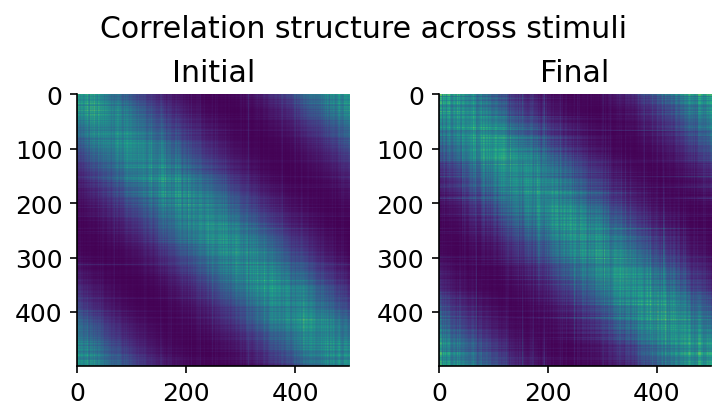

In [ ]:
corr_across_stim_initial = np.mean(corrs_initial, axis=2)
corr_across_stim_final = np.mean(corrs_final, axis=2)

fig, axs = plt.subplots(1, 2, figsize=(5, 3))
axs[0].imshow(corr_across_stim_initial)
axs[0].set_title("Initial")
# add colorbar
cbar0 = axs[0].collections[0].colorbar
cbar0.set_label("Correlation")

axs[1].imshow(corr_across_stim_final)
axs[1].set_title("Final")
cbar1 = axs[1].collections[0].colorbar
cbar1.set_label("Correlation")
fig.tight_layout()
fig.suptitle("Correlation structure across stimuli")
plt.show()

In [ ]:
corr_over_time = network.summed_corr_over_time(network.W)


100%|██████████| 841/841 [08:58<00:00,  1.56it/s]


(0.0, 0.002676298386826163)

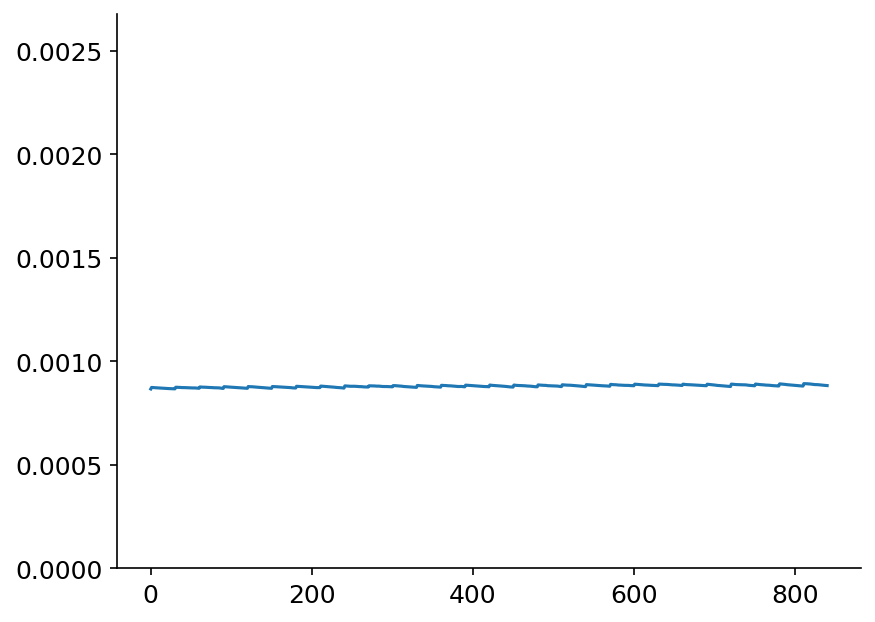

In [ ]:
plt.plot(corr_over_time)
plt.ylim(0, 3*max(corr_over_time))

In [18]:
corr_new = network.get_correlations_new(network.W[:, :, 0])

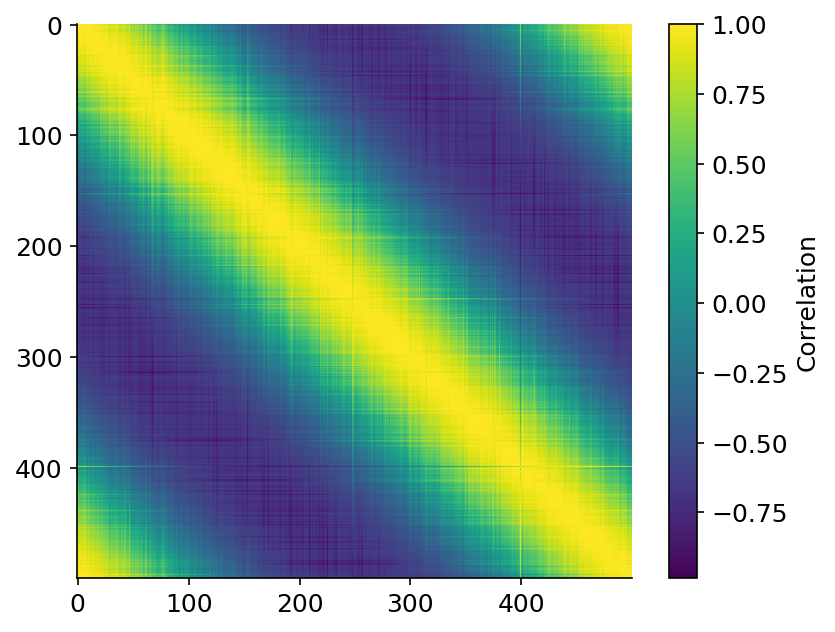

In [ ]:
plt.imshow(corr_new)
plt.colorbar(label="Correlation")